In [50]:
import cv2
import matplotlib.pyplot as plt
from IPython import display
import time
import numpy as np

In [93]:
path = r"100ml\trial1\4mm.mp4v"

In [94]:
cap = cv2.VideoCapture(path)

In [95]:
frames = []
frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break  # End of video reached
    frames.append(frame)
    frame_count += 1

In [105]:
new_frames = [np.dot(frame[..., :3], [0.114, 0.587, 0.299]) for frame in frames]
new_frames = [frame < 30 for frame in new_frames]

KeyboardInterrupt: 

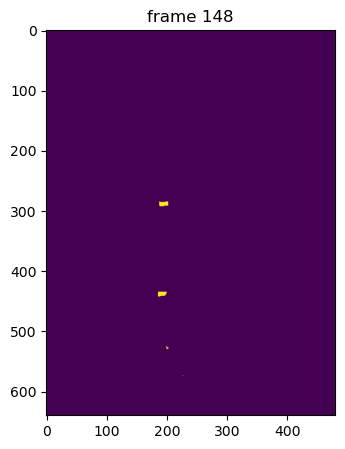

In [107]:
# set up figure, plot first frame
fig, ax = plt.subplots(1, 1, figsize=(6,5))

im = ax.imshow(new_frames[0])

for i in range(frame_count):
    im.set_data(new_frames[i])
    ax.set_title(f"frame {i}")
    # rerender
    display.display(plt.gcf())
    display.clear_output(wait=True)
    #time.sleep(0.2)

In [ ]:
frame_durations = {
    '6mm' : 5,
    '5mm' : 21
}

In [ ]:
frame_duration_6 = 42 - 27 
seconds_per_frame = 1 / 30
m_per_ml = 0.0185 / 20

time_duration_6 = frame_duration_6 * seconds_per_frame 
v_6 = 100*m_per_ml / time_duration_6

print(f"velocity in m/s: {v_6}")

0.0925
velocity in m/s: 0.185


In [89]:
def velocity(frame_duration):
    seconds_per_frame = 1 / 30
    m_per_ml = 0.0185 / 20
    return 100*m_per_ml / (frame_duration * seconds_per_frame)

In [92]:
print(velocity(21))

0.13214285714285715


In [77]:
def predicted_velocity(r):
    roB = 7700
    roG = 1261
    nu = 0.8
    V = 4 / 3 * np.pi * r**3
    return V * (roB * 9.81 - roG) / 6 / np.pi / nu / r

In [91]:
print(predicted_velocity(0.0025))

0.1289513888888889
